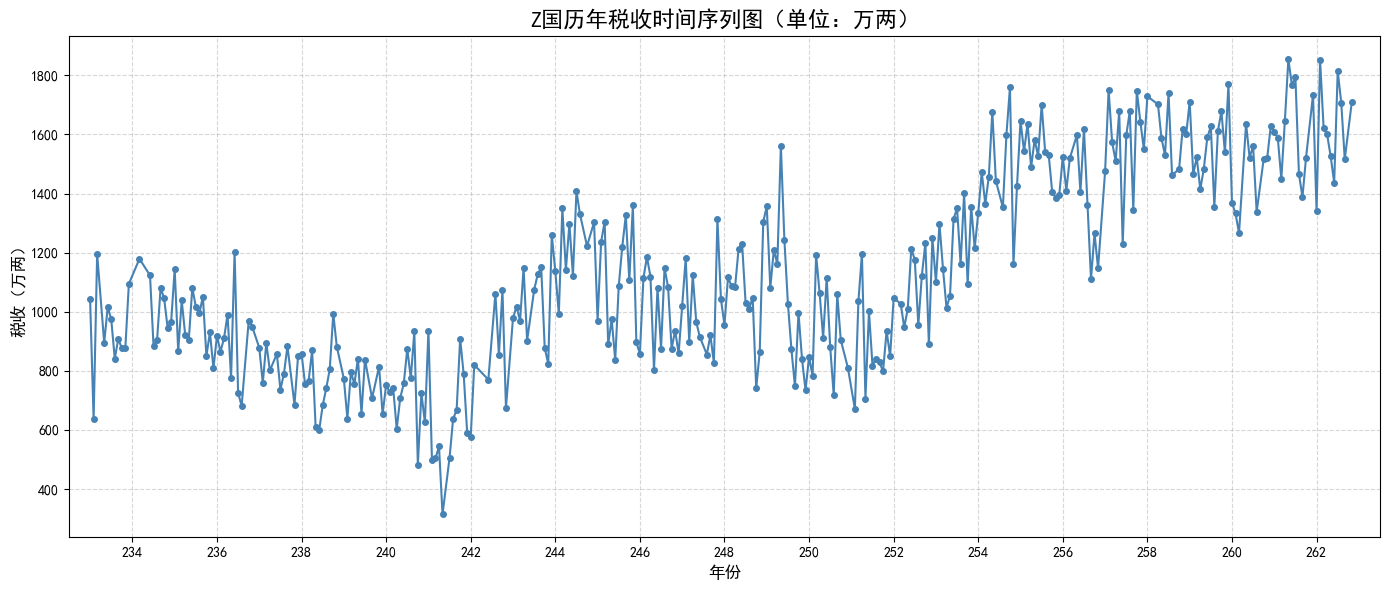

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于Windows显示中文
plt.rcParams['axes.unicode_minus'] = False

# 文件路径（使用原始字符串避免转义问题）
file_path = r"D:\数模协会\学术部\tax_data.csv"

# 读取CSV文件，处理可能的BOM头（utf-8-sig）
df = pd.read_csv(file_path, encoding='utf-8-sig')
# 确保列名正确（如果文件第一行有空格等，可以手动指定）
df.columns = ['年月', '税收']

# 删除税收为空的行（缺失值）
df = df.dropna(subset=['税收']).copy()

# 解析年月函数：提取年份和月份
def parse_year_month(s):
    try:
        # 例如 "Z国历233年1月" -> 233, 1
        year = int(s.split('年')[0].replace('Z国历', ''))
        month = int(s.split('年')[1].replace('月', ''))
        return year, month
    except:
        return None, None

# 应用解析
df['year'], df['month'] = zip(*df['年月'].apply(parse_year_month))

# 构造连续时间变量（年份 + (月份-1)/12，使时间均匀分布）
df['time'] = df['year'] + (df['month'] - 1) / 12

# 按时间排序，确保折线按顺序连接
df = df.sort_values('time').reset_index(drop=True)

# 绘制时间序列折线图（带数据点标记）
plt.figure(figsize=(14, 6))
plt.plot(df['time'], df['税收'], marker='o', linestyle='-', color='steelblue', markersize=4, linewidth=1.5)

# 图表装饰
plt.title('Z国历年税收时间序列图（单位：万两）', fontsize=16)
plt.xlabel('年份', fontsize=12)
plt.ylabel('税收（万两）', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
# 设置横轴刻度范围，根据数据年份适当调整
plt.xticks(range(230, 270, 2))
plt.xlim(232.5, 263.5)
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
import numpy as np
import re
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 读取数据（注意文件路径中的反斜杠需要转义或使用原始字符串）
file_path = r"D:\数模协会\学术部\tax_data.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')  # 假设文件编码为GBK

# 解析年月列，提取年份和月份
def parse_year_month(s):
    match = re.search(r'(\d+)年(\d+)月', str(s))
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return year, month
    return None, None

df[['year', 'month']] = df['年月'].apply(lambda x: pd.Series(parse_year_month(x)))

# 按年份和月份排序，确保时间顺序正确
df = df.sort_values(['year', 'month']).reset_index(drop=True)
# 创建时间序号（从1开始），便于插值
df['time'] = range(1, len(df) + 1)

# 原始税收列，缺失值为NaN
tax_original = df['税收（万两）']

# 方法1：线性插值（pandas内置，允许外推）
df_linear = df.copy()
df_linear['tax_linear'] = df_linear['税收（万两）'].interpolate(method='linear', limit_direction='both')
sum_linear = df_linear['tax_linear'].sum()

# 准备已知点（非缺失）和全部时间点
known_mask = tax_original.notna()
x_known = df.loc[known_mask, 'time'].values
y_known = df.loc[known_mask, '税收（万两）'].values
x_all = df['time'].values

# 方法2：二次插值（分段二次插值，使用scipy.interpolate.interp1d）
f_quad = interpolate.interp1d(x_known, y_known, kind='quadratic', fill_value='extrapolate')
y_quad = f_quad(x_all)
sum_quad = np.sum(y_quad)

# 方法3：三次样条插值（分段三次插值）
f_cubic = interpolate.interp1d(x_known, y_known, kind='cubic', fill_value='extrapolate')
y_cubic = f_cubic(x_all)
sum_cubic = np.sum(y_cubic)

# 方法4：线性回归填充（只填充缺失值，保留已知值）
X_train = x_known.reshape(-1, 1)
y_train = y_known
X_all = x_all.reshape(-1, 1)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr_pred = lr.predict(X_all)
df['tax_lr'] = df['税收（万两）'].fillna(pd.Series(y_lr_pred, index=df.index))
sum_lr = df['tax_lr'].sum()

# 方法5：二次多项式回归填充
poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly2.fit(X_train, y_train)
y_poly2_pred = poly2.predict(X_all)
df['tax_poly2'] = df['税收（万两）'].fillna(pd.Series(y_poly2_pred, index=df.index))
sum_poly2 = df['tax_poly2'].sum()

# 方法6：三次多项式回归填充
poly3 = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly3.fit(X_train, y_train)
y_poly3_pred = poly3.predict(X_all)
df['tax_poly3'] = df['税收（万两）'].fillna(pd.Series(y_poly3_pred, index=df.index))
sum_poly3 = df['tax_poly3'].sum()

# 方法7：向前填充（ffill）
df_ffill = df.copy()
# 先向前填充，再用向后填充处理开头的缺失
df_ffill['tax_ffill'] = df_ffill['税收（万两）'].ffill()
df_ffill['tax_ffill'] = df_ffill['tax_ffill'].bfill()  # 处理开头可能仍存在的NaN
sum_ffill = df_ffill['tax_ffill'].sum()

# 方法8：向后填充（bfill）
df_bfill = df.copy()
# 先后向填充，再用向前填充处理结尾的缺失
df_bfill['tax_bfill'] = df_bfill['税收（万两）'].bfill()
df_bfill['tax_bfill'] = df_bfill['tax_bfill'].ffill()  # 处理结尾可能仍存在的NaN
sum_bfill = df_bfill['tax_bfill'].sum()

# 方法9：中位数填充
median_val = tax_original.median()
df_median = df.copy()
df_median['tax_median'] = df_median['税收（万两）'].fillna(median_val)
sum_median = df_median['tax_median'].sum()

# 方法10：平均数填充
mean_val = tax_original.mean()
df_mean = df.copy()
df_mean['tax_mean'] = df_mean['税收（万两）'].fillna(mean_val)
sum_mean = df_mean['tax_mean'].sum()

# 方法11：众数填充（取第一个众数）
mode_val = tax_original.mode()[0]  # mode()返回Series，取第一个
df_mode = df.copy()
df_mode['tax_mode'] = df_mode['税收（万两）'].fillna(mode_val)
sum_mode = df_mode['tax_mode'].sum()

# 方法12：多项式插值（二阶，使用pandas interpolate）
df_poly_interp = df.copy()
# 使用多项式插值，order=2，并向两侧外推
df_poly_interp['tax_poly_interp'] = df_poly_interp['税收（万两）'].interpolate(
    method='polynomial', order=2, limit_direction='both'
)
sum_poly2_interp = df_poly_interp['tax_poly_interp'].sum()

# 方法13：多项式插值（三阶，使用pandas interpolate）
df_poly3_interp = df.copy()
df_poly3_interp['tax_poly3_interp'] = df_poly3_interp['税收（万两）'].interpolate(
    method='polynomial', order=3, limit_direction='both'
)
sum_poly3_interp = df_poly3_interp['tax_poly3_interp'].sum()

# ==================== 输出结果（保留整数，四舍五入） ====================
print("===== 各种方法计算得到的近三十年税收总和（万两，取整） =====")
print("线性插值总和: {:.0f}".format(sum_linear))
print("二次插值总和: {:.0f}".format(sum_quad))
print("三次样条插值总和: {:.0f}".format(sum_cubic))
print("线性回归填充总和: {:.0f}".format(sum_lr))
print("二次多项式回归填充总和: {:.0f}".format(sum_poly2))
print("三次多项式回归填充总和: {:.0f}".format(sum_poly3))
print("向前填充总和: {:.0f}".format(sum_ffill))
print("向后填充总和: {:.0f}".format(sum_bfill))
print("中位数填充总和: {:.0f}".format(sum_median))
print("平均数填充总和: {:.0f}".format(sum_mean))
print("众数填充总和: {:.0f}".format(sum_mode))
print("二阶多项式插值总和: {:.0f}".format(sum_poly2_interp))
print("三阶多项式插值总和: {:.0f}".format(sum_poly3_interp))

# 推荐使用三次样条插值结果作为密码（取整）
password = round(sum_cubic)
print("\n建议密码（三次样条插值总和取整）: {:.0f} 万两".format(password))

===== 各种方法计算得到的近三十年税收总和（万两，取整） =====
线性插值总和: 405232
二次插值总和: 405953
三次样条插值总和: 406047
线性回归填充总和: 404252
二次多项式回归填充总和: 405341
三次多项式回归填充总和: 405065
向前填充总和: 404526
向后填充总和: 405937
中位数填充总和: 404214
平均数填充总和: 405907
众数填充总和: 391992
二阶多项式插值总和: 403828
三阶多项式插值总和: 403780

建议密码（三次样条插值总和取整）: 406047 万两
